We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via: custom datasets.

### Domain libraries

Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions and customizable data loading functions.

In [1]:
import torch
from torch import nn
import requests 
import os
import zipfile
from pathlib import Path

## 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts with 3 classes of food and only 10% of the images (~75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [2]:
os.makedirs("data", exist_ok=True)
image_path = Path("data/pizza_steak_sushi")

# If the image folder doesn't exist, download it and prepare it...
if os.path.isdir(image_path):
    print(f"{image_path} is already exists...skipping download")
else:
    os.makedirs(image_path, exist_ok=True)
    print(f"{image_path} is not exists, creating new one...")

data/pizza_steak_sushi is already exists...skipping download


In [3]:
# Download pizza, steak and suhsi data
with open("data/pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    f.write(request.content)
    print("Downloading pizza, steak and sushi data...")

# Unzip pizza, steak, sushi data
with zipfile.ZipFile("data/pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)
    print("Unzipping pizza, steak and sushi data...")

TimeoutError: [Errno 60] Operation timed out

In [3]:
def walk_through_dir(dir_path):
    for dir_path, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directory and {len(filenames)} images in '{dir_path}'")

walk_through_dir(image_path)

There are 2 directory and 0 images in 'data/pizza_steak_sushi'
There are 3 directory and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directory and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directory and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directory and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 3 directory and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directory and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directory and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 1 directory and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directory and 1 images in 'data/pizza_steak_sushi/train/pizza/.ipynb_checkpoints'


In [4]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

Let's write some code to:

- Get all of the image paths
- Pick a random image path using Python's `random.choice()`
- Get the image class name using `pathlib.Path.parent.stem`
- Since we're working with images, let's open the image with Python's `PIL`
- We'll then show the image and print metadata

Image Path: data/pizza_steak_sushi/train/pizza/715169.jpg
Image class: pizza
Image height: 512
Image width: 512


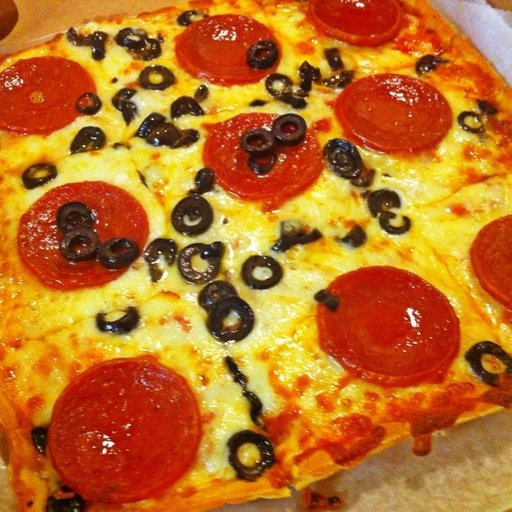

In [5]:
from PIL import Image
import random

# 1. Get all image paths 
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem   #Ex: parent= data/pizza_steak_sushi/train/pizza , stem= pizza

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata 
print(f"Image Path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

Image Class: pizza | Image shape: (512, 512, 3) -> [height, width, color channels] (HWC)


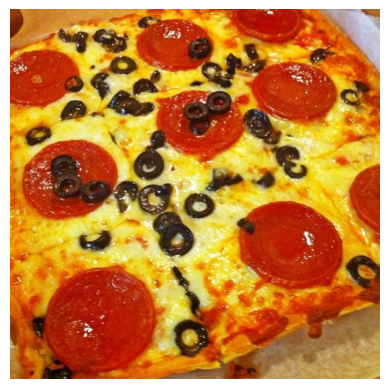

In [6]:
import matplotlib.pyplot as plt
import numpy as np

image_as_array = np.asarray(img)     # Turn the image into an array

plt.imshow(image_as_array)           # Plot the image with matplotlib
plt.axis(False)
print(f"Image Class: {image_class} | Image shape: {image_as_array.shape} -> [height, width, color channels] (HWC)");

## 3. Transforming data

Before we can use our image data with PyTorch:

Turn your target data into tensors (in our case, numerical representation of our images).               
Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` and `DataLoader`.

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with torchvision.transforms



In [8]:
# Write a transform for image
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),          # Resize our images to 64x64
    transforms.RandomHorizontalFlip(p=0.5),   # Flip the images randomly on the horizontal
    transforms.ToTensor()                     # Turn the image into a torch.Tensor
])

data_transform(img).shape

torch.Size([3, 64, 64])

Because `np.asarray(img)` follows the common image format used by NumPy and matplotlib: **HWC (height, width, channels)**.

But `transforms.ToTensor()` converts the image into PyTorch format, which is **CHW (channels, height, width)**.

So:
- NumPy / matplotlib → HWC
- PyTorch tensor → CHW

**ToTensor() changes both:**
1. the data type to a tensor
2.	the dimension order from HWC to CHW

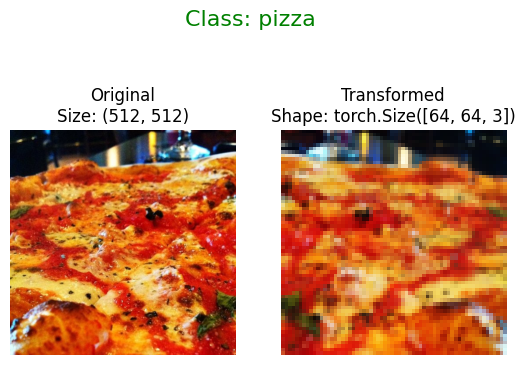

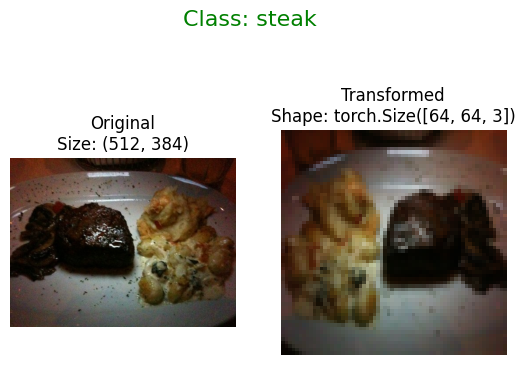

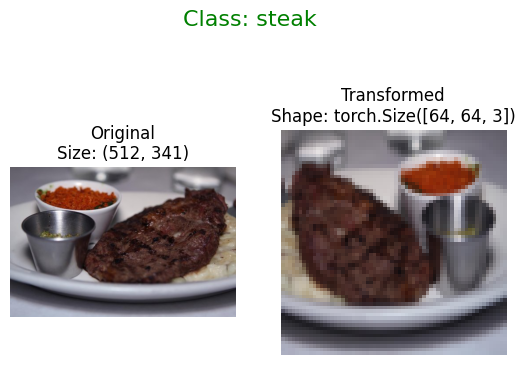

In [9]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    """
    Selects random images from a path of images and loads/transforms 
    them then plots the original vs the transformed version.
    """
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot target image
            transformed_image = transform(f).permute(1,2,0)   # note we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16, c="g")

plot_transformed_images(image_paths = image_path_list,
                       transform = data_transform,
                       n=3,
                       seed=42)

## 4. Option 1: Loading image data using ImageFolder

In [10]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets

#images -> tensor
train_data = datasets.ImageFolder(root = train_dir,
                                 transform = data_transform,     # a transform for the data
                                 target_transform = None)   #default=None   # a transform for the label/target

test_data = datasets.ImageFolder(root = test_dir,
                                transform = data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 226
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [11]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [12]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [13]:
len(train_data), len(test_data)

(226, 75)

In [14]:
train_data[0]

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [15]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

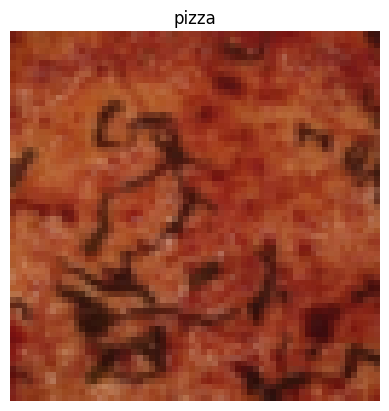

In [16]:
random_idx = torch.randint(0, len(train_data), size=[1]).item()
image, label = train_data[random_idx]
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);

### 4.1 Turn loaded images into DataLoader's

A `DataLoader` is going to help us turn our `Dataset`'s into iterables and we can customise the `batch_size` so our model can see `batch_size` images at a time.

In [17]:
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset = train_data,
                             batch_size = BATCH_SIZE,
                             num_workers = os.cpu_count(),   
                             shuffle = True)                

test_dataloader = DataLoader(dataset = test_data,
                            batch_size = BATCH_SIZE,
                            num_workers = os.cpu_count(),
                            shuffle = True)

#num_workers sets how many subprocesses are used to load the data.
#More workers can make data loading faster because batches are prepared in parallel.
len(train_dataloader), len(test_dataloader)

(226, 75)

In [18]:
os.cpu_count()

10

Now our data is iterable.

Let's try it out and check the shapes.

In [19]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 5. Option 2: Loading Image Data with a Custom Dataset

What if a pre-built `Dataset` creator like `torchvision.datasets.ImageFolder()` didn't exist?

Or one for your specific problem didn't exist?

Well, you could build your own.

But wait, what are the pros and cons of creating your own custom way to load `Dataset`'s?

**Pros**
- Can create a `Dataset` out of almost anything.
- Not limited to PyTorch pre-built `Dataset` functions.

**Cons**
- Even though you could create a `Dataset` out of almost anything, it doesn't mean it will work.
- Using a custom `Dataset` often results in writing more code, which could be prone to errors or performance issues.

To see this in action, let's work towards replicating `torchvision.datasets.ImageFolder()` by subclassing `torch.utils.data.Dataset` (the base class for all `Dataset`'s in PyTorch).

We'll start by importing the modules we need:

- Python's `os` for dealing with directories (our data is stored in directories).
- Python's `pathlib` for dealing with filepaths (each of our images has a unique filepath).
- `torch` for all things PyTorch.
- `PIL`'s `Image` class for loading images.
- `torch.utils.data.Dataset` to subclass and create our own custom `Dataset`.
- `torchvision.transforms` to turn our images into tensors.
- Various types from Python's `typing` module to add type hints to our code.
**Note:** You can customize the following steps for your own dataset. The premise remains: write code to load your data in the format you'd like it.

In [21]:
import os
import torch
import pathlib
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Dict, List, Tuple

Remember how our instances of `torchvision.datasets.ImageFolder()` allowed us to use the `classes` and `class_to_idx attributes`?

In [25]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

Let's write a helper function capable of creating a list of class names and a dictionary of class names and their indexes given a directory path.

To do so, we'll:

- Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
- Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
- Turn the class names into a dictionary of numerical labels, one for each class.
  
Let's see a small example of step 1 before we write the full function.

In [27]:
target_dir = train_dir                            # Setup path for target directory
print(f"Target directory: {target_dir}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))])   # Get the class names from the target directory
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


How about we turn it into a full function?

In [28]:
def find_classes(dictionary: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
     # 1. Get the class names by scanning the target directory
    class_names = sorted([entry.name for entry in os.scandir(dictionary)])

    # 2. Raise an error if class names not found
    if not class_names:
        raise FileNotFoundError(f"Couldn't not found any classes in {dictionary}")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}
    return class_names, class_to_idx

find_classes(train_dir)
        

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

Now we're ready to build our own custom `Dataset`.

We'll build one to replicate the functionality of `torchvision.datasets.ImageFolder()`.

This will be good practice, plus, it'll reveal a few of the required steps to make your own custom `Dataset`.

It'll be a fair bit of a code... but nothing we can't handle!

**Let's break it down:**

1. Subclass `torch.utils.data.Dataset`.
2. Initialize our subclass with a `targ_dir` parameter (the target data directory) and `transform` parameter (so we have the option to transform our data if needed).
3. Create several attributes for `paths` (the paths of our target images), `transform` (the transforms we might like to use, this can be `None`), `classes` and `class_to_idx` (from our `find_classes()` function).
4. Create a function to load images from file and return them, this could be using `PIL` or `torchvision.io` (for input/output of vision data).
5. Overwrite the `__len__` method of `torch.utils.data.Dataset` to return the number of samples in the `Dataset`, this is recommended but not required. This is so you can call `len(Dataset)`.
6. Overwrite the `__getitem__` method of `torch.utils.data.Dataset` to return a single sample from the `Dataset`, this is required.

In [29]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform: None) -> None:

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))  # note: you'd have to update this if you've got .png's or .jpeg's
        self.transform = transform                                 # Setup transforms
        self.classes, self.class_to_idx = find_classes(targ_dir)   # Create classes and class_to_idx attributes

    
    # 4. Make function to load images
    def load_image(self, index: int):                             
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:       
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor(), int]: 
        img = load_image(index)
        class_name = self.paths[index].parent.name    # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx    # return data, label (X, y)
        else:
            return img, class_idx   # return data, label (X, y)
        
    

Before we test out our new `ImageFolderCustom` class, let's create some `transforms` to prepare our images.

Let's turn our training images (contained in `train_dir`) and our testing images (contained in `test_dir`) into `Dataset`'s using our own
`ImageFolderCustom` class.

In [33]:
from torchvision import transforms

# Augment train data
train_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                               transforms.RandomHorizontalFlip(p=0.5),
                               transforms.ToTensor()])

# Don't augment test data, only reshape
test_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                               transforms.ToTensor()])

train_data_custom = ImageFolderCustom(targ_dir = train_dir, transform = train_transform)
test_data_custom= ImageFolderCustom(targ_dir = test_dir, transform = test_transform)

In [34]:
len(train_data), len(train_data_custom)

(226, 225)

In [35]:
len(test_data), len(test_data)

(75, 75)

In [38]:
train_data

Dataset ImageFolder
    Number of datapoints: 226
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [39]:
train_data_custom.classes, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})